# 02 — Exploratory Data Analysis

Goal: understand feature patterns using the internal training partition.

The saved split assignments determine which rows we explore.
Validation and official test data are reserved for evaluation.

First question: how many normal and attack records are in training?

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Locate the project from the notebooks folder.
project_root = Path.cwd().parent

# Load the original training file and our saved partition assignments.
source_df = pd.read_csv(project_root / "data" / "raw" / "UNSW_NB15_training-set.csv")
split_assignments = pd.read_csv(project_root / "data" / "processed" / "train_validation_split.csv")

# Select the IDs assigned to internal training.
training_ids = split_assignments.loc[
    split_assignments["partition"].eq("training"),
    "id",
]

# Recover those records from the original table.
fit_df = source_df.loc[source_df["id"].isin(training_ids)].copy()

# Check that every requested training record was recovered.
assert training_ids.is_unique
assert len(fit_df) == len(training_ids)

fit_df.shape

(140272, 45)

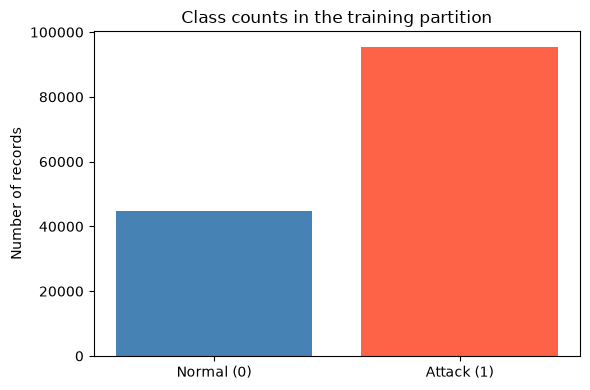

In [2]:
# Count each class and order the results as 0, then 1.
label_counts = fit_df["label"].value_counts().sort_index()

# Create a figure containing one plotting area.
fig, ax = plt.subplots(figsize=(6, 4))

# Category names go on the horizontal axis; counts determine bar heights.
ax.bar(
    ["Normal (0)", "Attack (1)"],
    label_counts,
    color=["steelblue", "tomato"],
)

# Explain what the chart displays.
ax.set_title("Class counts in the training partition")
ax.set_ylabel("Number of records")

plt.tight_layout()
plt.show()

In [3]:
# Count normal and attack records separately for each service.
service_summary = pd.crosstab(
    fit_df["service"],
    fit_df["label"],
)

# Replace binary column labels with readable names.
service_summary = service_summary.rename(
    columns={0: "normal", 1: "attack"}
)

# Calculate the number of records and attack percentage within each service.
service_summary["total"] = (service_summary["normal"] + service_summary["attack"])
service_summary["attack_percentage"] = (service_summary["attack"] / service_summary["total"] * 100)

# Show the most frequently observed services first.
service_summary = service_summary.sort_values("total", ascending=False)

service_summary.round(2)

label,normal,attack,total,attack_percentage
service,,,,
-,29221,45994,75215,61.15
dns,6014,32011,38025,84.18
http,4266,10644,14910,71.39
smtp,1281,2791,4072,68.54
ftp-data,2034,1205,3239,37.20
ftp,959,1724,2683,64.26
ssh,1020,10,1030,0.97
pop3,4,889,893,99.55
dhcp,0,72,72,100.00


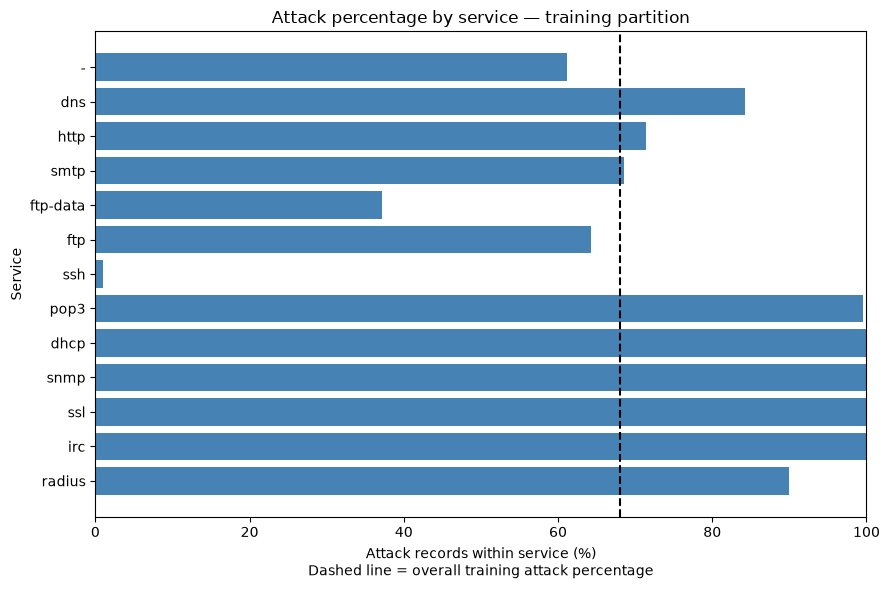

In [4]:
# Calculate the overall attack percentage as a reference.
overall_attack_percentage = fit_df["label"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 6))

# Show the attack percentage within each service.
ax.barh(
    service_summary.index,
    service_summary["attack_percentage"],
    color="steelblue",
)

# Draw a reference line at the overall training attack percentage.
ax.axvline(
    overall_attack_percentage,
    color="black",
    linestyle="--",
)

# Keep the most common services at the top, matching the table.
ax.invert_yaxis()

ax.set_xlim(0, 100)
ax.set_ylabel("Service")
ax.set_xlabel(
    "Attack records within service (%)\n"
    "Dashed line = overall training attack percentage"
)
ax.set_title("Attack percentage by service — training partition")

plt.tight_layout()
plt.show()

In [5]:
# Summarize source-byte counts, including the upper end of the distribution.
fit_df["sbytes"].describe(
    percentiles=[0.50, 0.90, 0.99]
).round(2)

count      140272.00
mean         8936.79
std        177356.78
min            46.00
50%           424.00
90%          4172.00
99%         70349.00
max      12965233.00
Name: sbytes, dtype: float64

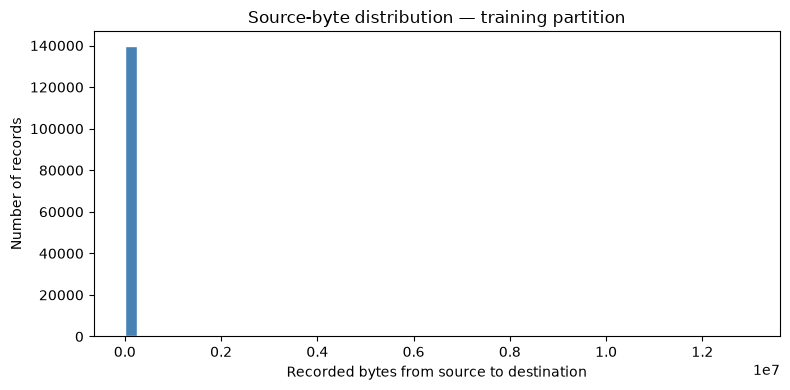

In [6]:
# Divide the observed byte range into 50 intervals and count records in each.
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    fit_df["sbytes"],
    bins=50,
    color="steelblue",
    edgecolor="white",
)

ax.set_title("Source-byte distribution — training partition")
ax.set_xlabel("Recorded bytes from source to destination")
ax.set_ylabel("Number of records")

plt.tight_layout()
plt.show()

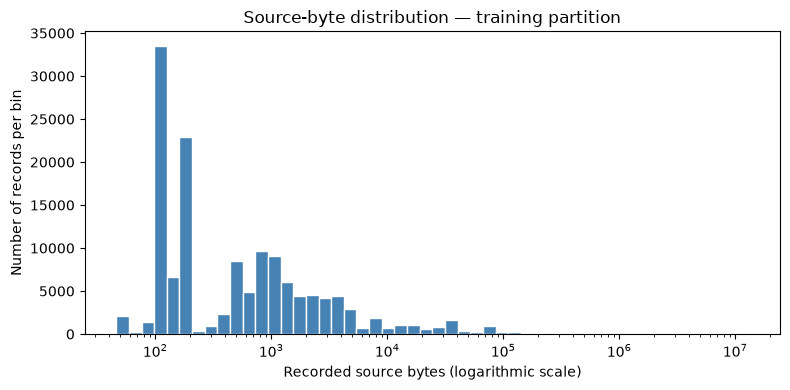

In [7]:
import numpy as np

# Select the source-byte measurements.
sbytes = fit_df["sbytes"]

# Create 51 boundaries, giving 50 bins equally spaced on a log scale.
bin_edges = np.geomspace(sbytes.min(), sbytes.max(), num=51)

fig, ax = plt.subplots(figsize=(8, 4))

# Count all records using the new bin boundaries.
ax.hist(
    sbytes,
    bins=bin_edges,
    color="steelblue",
    edgecolor="white",
)

# Display equal ratios as equal distances along the horizontal axis.
ax.set_xscale("log")

ax.set_title("Source-byte distribution — training partition")
ax.set_xlabel("Recorded source bytes (logarithmic scale)")
ax.set_ylabel("Number of records per bin")

plt.tight_layout()
plt.show()

In [8]:
# Calculate source-byte statistics separately for each binary label.
sbytes_by_label = fit_df.groupby("label")["sbytes"].describe(
    percentiles=[0.50, 0.90, 0.99]
)

# Give the two rows readable names.
sbytes_by_label = sbytes_by_label.rename(
    index={0: "Normal", 1: "Attack"}
)

# Display the statistics we want to compare.
sbytes_by_label[
    ["count", "mean", "50%", "90%", "99%", "max"]
].round(2)

,count,mean,50%,90%,99%,max
label,,,,,,
Normal,44800.0,4101.70,1470.0,7818.0,37938.00,338718.0
Attack,95472.0,11205.64,200.0,2184.0,121445.18,12965233.0


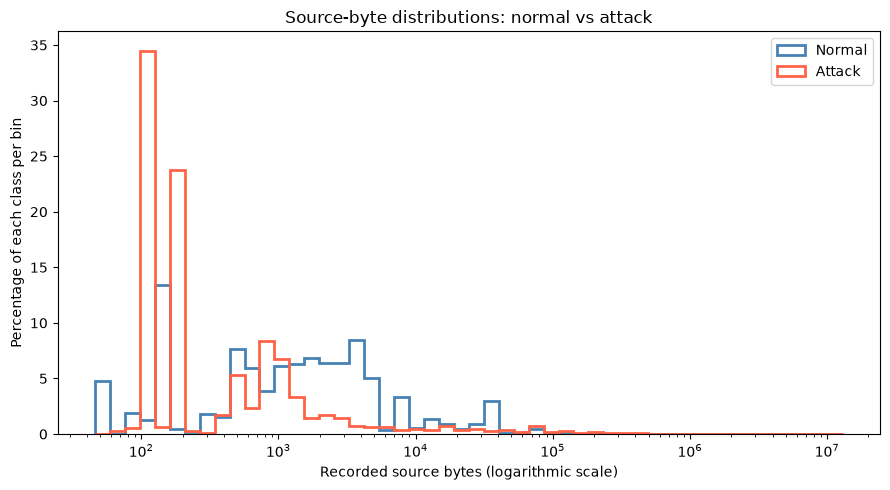

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

# Draw one histogram for each class using the same byte intervals.
for label, name, color in [
    (0, "Normal", "steelblue"),
    (1, "Attack", "tomato"),
]:
    # Select source-byte values belonging to this class.
    values = fit_df.loc[fit_df["label"].eq(label), "sbytes"]

    # Each record contributes its percentage of this class.
    weights = np.full(len(values), 100 / len(values))

    # Draw outlines so both distributions remain visible.
    ax.hist(
        values,
        bins=bin_edges,
        weights=weights,
        histtype="step",
        linewidth=2,
        color=color,
        label=name,
    )

ax.set_xscale("log")
ax.set_xlabel("Recorded source bytes (logarithmic scale)")
ax.set_ylabel("Percentage of each class per bin")
ax.set_title("Source-byte distributions: normal vs attack")
ax.legend()

plt.tight_layout()
plt.show()

The source-byte distributions differ between normal and attack records.
Attack records are strongly concentrated around small byte counts, while
normal records are more broadly distributed across larger values.

The distributions overlap across several intervals, so the plot does not
show a clean separation using a single byte-count cutoff. Source bytes
may be useful alongside other features; predictive usefulness must be
checked through validation.

In [10]:
# For each class, count records with zero versus nonzero destination bytes.
response_summary = pd.crosstab(
    fit_df["label"],
    fit_df["dbytes"].eq(0),
)

# Replace binary and Boolean labels with readable names.
response_summary = response_summary.rename(
    index={0: "Normal", 1: "Attack"},
    columns={False: "nonzero_bytes", True: "zero_bytes"},
)

# Calculate the percentage with zero destination bytes within each class.
response_summary["total"] = (
    response_summary["nonzero_bytes"] + response_summary["zero_bytes"]
)
response_summary["zero_bytes_percentage"] = (
    response_summary["zero_bytes"] / response_summary["total"] * 100
)

response_summary.round(2)

dbytes,nonzero_bytes,zero_bytes,total,zero_bytes_percentage
label,,,,
Normal,39440,5360,44800,11.96
Attack,33298,62174,95472,65.12


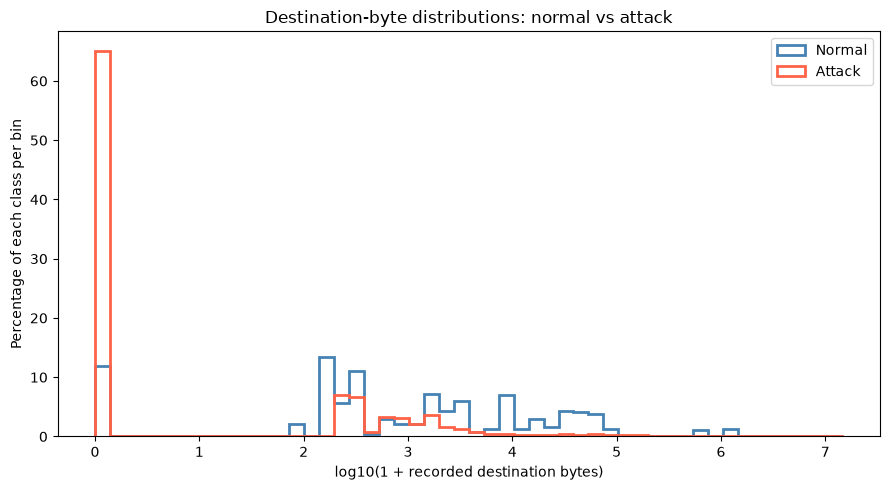

In [11]:
# Transform values for plotting, keeping zero-byte records included.
dbytes_log = np.log10(fit_df["dbytes"] + 1)

# Create 50 shared bins across the transformed range.
dbytes_bins = np.linspace(
    dbytes_log.min(),
    dbytes_log.max(),
    num=51,
)

fig, ax = plt.subplots(figsize=(9, 5))

for label, name, color in [
    (0, "Normal", "steelblue"),
    (1, "Attack", "tomato"),
]:
    # Select transformed values for this class.
    values = dbytes_log.loc[fit_df["label"].eq(label)]

    # Express bin heights as percentages within this class.
    weights = np.full(len(values), 100 / len(values))

    ax.hist(
        values,
        bins=dbytes_bins,
        weights=weights,
        histtype="step",
        linewidth=2,
        color=color,
        label=name,
    )

# The values are already transformed, so use an ordinary linear axis.
ax.set_xlabel("log10(1 + recorded destination bytes)")
ax.set_ylabel("Percentage of each class per bin")
ax.set_title("Destination-byte distributions: normal vs attack")
ax.legend()

plt.tight_layout()
plt.show()

Zero destination bytes are substantially more common among attack records. However, both classes contain zero-byte records and overlap across positive-byte intervals, so destination bytes alone cannot perfectly distinguish the classes.

In [12]:
# Select numerical features whose network meanings we have discussed.
numerical_features = [
    "dur",
    "spkts",
    "dpkts",
    "sbytes",
    "dbytes",
]

# Compare feature rankings using only the internal training partition.
correlations = fit_df[numerical_features].corr(method="spearman")

correlations.round(2)

,dur,spkts,dpkts,sbytes,dbytes
dur,1.00,0.82,0.77,0.75,0.76
spkts,0.82,1.00,0.91,0.90,0.89
dpkts,0.77,0.91,1.00,0.81,0.99
sbytes,0.75,0.90,0.81,1.00,0.79
dbytes,0.76,0.89,0.99,0.79,1.00


Packet counts and byte counts have strong positive Spearman correlations,
particularly dpkts and dbytes (0.99, rounded). Duration also has a positive
relationship with packet counts.

These features contain related information. We will retain them initially
and evaluate feature-selection decisions using validation results.

In [13]:
# Count normal and attack records within each state.
state_summary = pd.crosstab(
    fit_df["state"],
    fit_df["label"],
).rename(columns={0: "normal", 1: "attack"})

# Calculate each state's record count and attack percentage.
state_summary["total"] = (
    state_summary["normal"] + state_summary["attack"]
)
state_summary["attack_percentage"] = (
    state_summary["attack"] / state_summary["total"] * 100
)

# Put the most frequently observed states first.
state_summary = state_summary.sort_values("total", ascending=False)

state_summary.round(2)

label,normal,attack,total,attack_percentage
state,,,,
INT,4622,61265,65887,92.98
FIN,29657,32470,62127,52.26
CON,9729,818,10547,7.76
REQ,724,909,1633,55.66
RST,55,10,65,15.38
ECO,11,0,11,0.00
PAR,1,0,1,0.00
URN,1,0,1,0.00


Attack proportions differ substantially across recorded states.
INT is predominantly attack, CON is predominantly normal, and FIN
contains substantial numbers of both classes.

Rare states have too few observations for strong conclusions.
State may contribute useful information alongside other features.

In [14]:
# Count normal and attack records within each protocol.
protocol_summary = pd.crosstab(
    fit_df["proto"],
    fit_df["label"],
).rename(columns={0: "normal", 1: "attack"})

# Calculate each protocol's total and attack percentage.
protocol_summary["total"] = (
    protocol_summary["normal"] + protocol_summary["attack"]
)
protocol_summary["attack_percentage"] = (
    protocol_summary["attack"] / protocol_summary["total"] * 100
)

# Sort by frequency and display the ten most common protocols.
protocol_summary = protocol_summary.sort_values("total", ascending=False)

print("Protocol categories in training:", len(protocol_summary))
protocol_summary.head(10).round(2)

Protocol categories in training: 133


label,normal,attack,total,attack_percentage
proto,,,,
tcp,31225,32602,63827,51.08
udp,11190,39758,50948,78.04
unas,0,9252,9252,100.00
arp,2305,0,2305,0.00
ospf,50,2029,2079,97.59
sctp,0,908,908,100.00
any,0,259,259,100.00
gre,0,225,225,100.00
mobile,0,201,201,100.00


In [15]:
# Inspect only candidate inputs from the internal training partition.
candidate_inputs = fit_df.drop(columns=["id", "attack_cat", "label"])

# Record missing-value counts and the number of distinct values.
feature_audit = pd.DataFrame({
    "missing": candidate_inputs.isna().sum(),
    "unique_values": candidate_inputs.nunique(dropna=False),
})

# Measure how much of each column is occupied by its most common value.
for column in candidate_inputs.columns:
    proportions = candidate_inputs[column].value_counts(
        normalize=True,
        dropna=False,
    )
    feature_audit.loc[column, "most_common_percentage"] = (
        proportions.iloc[0] * 100
    )

# Check numerical inputs for positive or negative infinity.
numeric_inputs = candidate_inputs.select_dtypes(include="number")

print("Missing input cells:", feature_audit["missing"].sum())
print("Infinite numeric values:", np.isinf(numeric_inputs).sum().sum())

# Identify columns containing exactly one distinct value.
constant_columns = feature_audit.index[
    feature_audit["unique_values"].eq(1)
].tolist()
print("Constant input columns:", constant_columns)

# Display the ten columns most dominated by one value.
feature_audit.sort_values(
    "most_common_percentage",
    ascending=False,
).head(10).round(2)

Missing input cells: 0
Infinite numeric values: 0
Constant input columns: []


,missing,unique_values,most_common_percentage
is_ftp_login,0,4,98.55
ct_ftp_cmd,0,4,98.55
is_sm_ips_ports,0,2,98.41
response_body_len,0,2092,93.57
ct_flw_http_mthd,0,11,89.87
trans_depth,0,11,89.87
sttl,0,11,65.44
ct_dst_sport_ltm,0,31,62.47
dloss,0,340,55.18
ackdat,0,31653,55.00


## EDA conclusions

- Exploration used only the internal training partition: 140,272 records.
- Approximately 68.06% of training records are attacks.
- Attack proportions differ across services, states, and protocols.
  These are dataset observations, not universal networking rules.
- Source-byte counts are strongly right-skewed. Normal records have a
  larger median, while attack records have a heavier upper tail.
- Zero destination bytes occur in 65.12% of attack records and 11.96%
  of normal records. This feature alone cannot perfectly separate classes.
- Packet counts and byte counts are strongly correlated.
- Candidate training inputs contain no pandas-recognized missing values,
  infinite numerical values, or constant columns.
- Several features are dominated by one value; rare values may still
  contain useful information.
- Exact duplicate features and ambiguous FTP values require explicit
  decisions during feature selection and preprocessing.
- Logarithmic views were used for visualization. Model preprocessing
  has not yet been fitted.